<a href="https://colab.research.google.com/github/SAINIDHI2005/IDS_GNN_Repo/blob/main/graphSAGE/HostFlowTemporal_testing123.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!pip install torch-geometric -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.4/64.4 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 34.5 MB/s eta 0:00:00


In [3]:
import os

import pandas as pd
import numpy as np

import torch

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

from torch_geometric.data import Data
from torch_geometric.nn.dense.linear import Linear as PyGLinear

In [4]:
import copy
import time
import matplotlib.pyplot as plt

import torch.nn.utils.prune as prune

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

In [5]:
DATASET_DIR = "/content/drive/MyDrive/CIC_IoT_2023/New_Disjoint_200K"


dfs = []

# -------------------------
# BENIGN
# -------------------------

benign = pd.read_csv(
    os.path.join(DATASET_DIR, "Benign_100K.csv")
)

benign = benign.iloc[:90000].copy()

benign["attack_type"] = "BENIGN"
benign["label"] = 0

dfs.append(benign)

# -------------------------
# DDOS
# -------------------------

ddos = pd.read_csv(
    os.path.join(DATASET_DIR, "DDoS_20K.csv")
)

ddos = ddos.iloc[:2000].copy()

ddos["attack_type"] = "DDoS_20K"
ddos["label"] = 1

dfs.append(ddos)

# -------------------------
# DOS
# -------------------------

dos = pd.read_csv(
    os.path.join(DATASET_DIR, "DoS_20K.csv")
)

dos = dos.iloc[:2000].copy()

dos["attack_type"] = "DoS_20K"
dos["label"] = 1

dfs.append(dos)

# -------------------------
# MIRAI
# -------------------------

mirai = pd.read_csv(
    os.path.join(DATASET_DIR, "Mirai_20K.csv")
)

mirai = mirai.iloc[:2000].copy()

mirai["attack_type"] = "Mirai_20K"
mirai["label"] = 1

dfs.append(mirai)

# -------------------------
# RECON
# -------------------------

recon = pd.read_csv(
    os.path.join(DATASET_DIR, "Recon_20K.csv")
)

recon = recon.iloc[:2000].copy()

recon["attack_type"] = "Recon_20K"
recon["label"] = 1

dfs.append(recon)

# -------------------------
# SPOOFING
# -------------------------

spoof = pd.read_csv(
    os.path.join(DATASET_DIR, "Spoofing_20K.csv")
)

spoof = spoof.iloc[:2000].copy()

spoof["attack_type"] = "Spoofing_20K"
spoof["label"] = 1

dfs.append(spoof)

# -------------------------
# COMBINE
# -------------------------

data = pd.concat(
    dfs,
    ignore_index=True
)

print(data.shape)

print("\nAttack Distribution:\n")
print(data["attack_type"].value_counts())

(100000, 88)

Attack Distribution:

attack_type
BENIGN          90000
DDoS_20K         2000
DoS_20K          2000
Mirai_20K        2000
Recon_20K        2000
Spoofing_20K     2000
Name: count, dtype: int64


In [6]:
data = data.sort_values(
    "bidirectional_first_seen_ms"
).reset_index(drop=True)

data["flow_id"] = np.arange(len(data))

print(data.shape)

(100000, 89)


In [7]:
attack_type_backup = data["attack_type"].copy()

In [8]:
DROP_COLS = [

    "id",
    "expiration_id",

    "src_ip",
    "dst_ip",


   # "dst_port",
    #"src_port",
    #"protocol",
   # "ip_version"

    "src_mac",
    "dst_mac",

    "src_oui",
    "dst_oui",

    "requested_server_name",

    "client_fingerprint",
    "server_fingerprint",

    "user_agent",
    "content_type",

    "application_name",
    "application_category_name",

    "flow_id",
    "label",
    "attack_type",

    "bidirectional_first_seen_ms",
    "bidirectional_last_seen_ms",

    "src2dst_first_seen_ms",
    "src2dst_last_seen_ms",

    "dst2src_first_seen_ms",
    "dst2src_last_seen_ms",

    "application_confidence",
    "application_is_guessed",

    "vlan_id",
    "tunnel_id",

    "bidirectional_urg_packets",
    "src2dst_urg_packets",
    "dst2src_urg_packets",

    "dst2src_cwr_packets",
    "dst2src_ece_packets",

    "src_port",

    "bidirectional_duration_ms",
    "bidirectional_packets",

    "src2dst_packets",
    "dst2src_packets",

    "dst2src_min_ps",
    "dst2src_mean_ps",

    "bidirectional_min_piat_ms",
    "bidirectional_stddev_piat_ms",

    "dst2src_min_piat_ms",
    "dst2src_mean_piat_ms",
    "dst2src_max_piat_ms",

    "bidirectional_ece_packets",
    "bidirectional_psh_packets",
    "bidirectional_fin_packets",

    "src2dst_syn_packets",
    "src2dst_cwr_packets",
    "src2dst_ack_packets",
    "src2dst_rst_packets",
    "src2dst_fin_packets",

    "src2dst_mean_piat_ms",
    "src2dst_stddev_ps",

    "dst2src_ack_packets",
    "dst2src_psh_packets",
    "dst2src_rst_packets",
    "dst2src_fin_packets",

]

feature_cols = [

    c
    for c in data.columns
    if c not in DROP_COLS
]

print("Features:",len(feature_cols))

Features: 30


In [9]:
feature_cols = [
    c
    for c in data.columns
    if c not in DROP_COLS
]

print("Features:", len(feature_cols))

print("\nRetained Features:\n")
for i, f in enumerate(feature_cols, start=1):
    print(f"{i:2d}. {f}")

Features: 30

Retained Features:

 1. dst_port
 2. protocol
 3. ip_version
 4. bidirectional_bytes
 5. src2dst_duration_ms
 6. src2dst_bytes
 7. dst2src_duration_ms
 8. dst2src_bytes
 9. bidirectional_min_ps
10. bidirectional_mean_ps
11. bidirectional_stddev_ps
12. bidirectional_max_ps
13. src2dst_min_ps
14. src2dst_mean_ps
15. src2dst_max_ps
16. dst2src_stddev_ps
17. dst2src_max_ps
18. bidirectional_mean_piat_ms
19. bidirectional_max_piat_ms
20. src2dst_min_piat_ms
21. src2dst_stddev_piat_ms
22. src2dst_max_piat_ms
23. dst2src_stddev_piat_ms
24. bidirectional_syn_packets
25. bidirectional_cwr_packets
26. bidirectional_ack_packets
27. bidirectional_rst_packets
28. src2dst_ece_packets
29. src2dst_psh_packets
30. dst2src_syn_packets


In [10]:
top30 = {
    "bidirectional_mean_ps",
    "dst2src_syn_packets",
    "src2dst_min_ps",
    "ip_version",
    "src2dst_max_piat_ms",
    "dst2src_stddev_piat_ms",
    "bidirectional_max_piat_ms",
    "bidirectional_rst_packets",
    "src2dst_max_ps",
    "src2dst_duration_ms",
    "src2dst_bytes",
    "src2dst_ece_packets",
    "bidirectional_max_ps",
    "dst2src_bytes",
    "bidirectional_bytes",
    "dst2src_max_ps",
    "bidirectional_min_ps",
    "bidirectional_syn_packets",
    "dst2src_stddev_ps",
    "bidirectional_ack_packets",
    "protocol",
    "dst_port",
    "bidirectional_mean_piat_ms",
    "dst2src_duration_ms",
    "src2dst_mean_ps",
    "src2dst_min_piat_ms",
    "bidirectional_stddev_ps",
    "src2dst_stddev_piat_ms",
    "bidirectional_cwr_packets",
    "src2dst_psh_packets"
}

retained = set(feature_cols)

print("Missing from retained:")
print(sorted(top30 - retained))

print("\nExtra retained features:")
print(sorted(retained - top30))

Missing from retained:
[]

Extra retained features:
[]


In [11]:
for col in feature_cols:

    data[col] = pd.to_numeric(
        data[col],
        errors="coerce"
    )

data[feature_cols] = (
    data[feature_cols]
    .fillna(0)
)

In [12]:
import joblib

scaler = joblib.load(
    r"/content/drive/MyDrive/CIC_IoT_2023/Saved_Model/HostFlowTemporal_scaler_imp123.pkl"
)

X = scaler.transform(
    data[feature_cols]
)

print(X.shape)

(100000, 30)


In [13]:
all_hosts = pd.concat(
    [
        data["src_ip"],
        data["dst_ip"]
    ]
).unique()

host_to_id = {

    host : idx + len(data)

    for idx,host
    in enumerate(all_hosts)
}

num_flow_nodes = len(data)

num_host_nodes = len(all_hosts)

print("Flow Nodes:",num_flow_nodes)
print("Host Nodes:",num_host_nodes)

Flow Nodes: 100000
Host Nodes: 1767


In [14]:
edges = []

for flow_id,row in data.iterrows():

    src_host = host_to_id[
        row["src_ip"]
    ]

    dst_host = host_to_id[
        row["dst_ip"]
    ]

    edges.append(
        [flow_id,src_host]
    )

    edges.append(
        [src_host,flow_id]
    )

    edges.append(
        [flow_id,dst_host]
    )

    edges.append(
        [dst_host,flow_id]
    )

print("Host-flow edges built")

Host-flow edges built


In [15]:
src_groups = data.groupby(
    "src_ip"
)["flow_id"].apply(list)

print(
    "Groups:",
    len(src_groups)
)

Groups: 541


In [16]:
# ==================================
# TEMPORAL FLOW-FLOW EDGES
# ==================================

src_groups = data.groupby("src_ip")["flow_id"].apply(list)

temporal_edges = 0

for flow_list in src_groups:

    n = len(flow_list)

    if n < 2:
        continue

    for i in range(n):

        f1 = flow_list[i]

        for k in [1, 2, 3]:

            if i + k < n:

                f2 = flow_list[i + k]

                edges.append([f1, f2])
                edges.append([f2, f1])

                temporal_edges += 2

print("Temporal edges added:", temporal_edges)
print("Total edges:", len(edges))

Temporal edges added: 594796
Total edges: 994796


In [17]:
edge_index = torch.tensor(edges,dtype=torch.long).t().contiguous()
print(edge_index.shape)



torch.Size([2, 994796])


In [18]:
flow_features = torch.tensor(
    X,
    dtype=torch.float
)

In [19]:
host_features = torch.zeros(

    (
        num_host_nodes,
        flow_features.shape[1]
    ),

    dtype=torch.float
)

host_counts = np.zeros(
    num_host_nodes
)

for flow_id,row in data.iterrows():

    src_idx = (
        host_to_id[
            row["src_ip"]
        ]
        -
        num_flow_nodes
    )

    dst_idx = (
        host_to_id[
            row["dst_ip"]
        ]
        -
        num_flow_nodes
    )

    host_features[src_idx] += flow_features[flow_id]
    host_features[dst_idx] += flow_features[flow_id]

    host_counts[src_idx] += 1
    host_counts[dst_idx] += 1

for i in range(num_host_nodes):

    if host_counts[i] > 0:

        host_features[i] /= (
            host_counts[i]
        )

In [20]:
x = torch.cat(
    [
        flow_features,
        host_features
    ],
    dim=0
)

print(x.shape)

torch.Size([101767, 30])


In [21]:
flow_labels = torch.tensor(
    data["label"].values,
    dtype=torch.long
)

host_labels = torch.full(
    (
        num_host_nodes,
    ),
    -1,
    dtype=torch.long
)

y = torch.cat(
    [
        flow_labels,
        host_labels
    ]
)

print(y.shape)

torch.Size([101767])


In [22]:
graph = Data(
    x=x,
    edge_index=edge_index,
    y=y
)

print(graph)
print("Nodes:", graph.num_nodes)
print("Edges:", graph.num_edges)

Data(x=[101767, 30], edge_index=[2, 994796], y=[101767])
Nodes: 101767
Edges: 994796


In [23]:
import torch
import torch.nn.functional as F

from torch_geometric.nn import SAGEConv

class GraphSAGE(torch.nn.Module):

    def __init__(
        self,
        in_channels,
        hidden_channels,
        num_classes
    ):

        super().__init__()

        self.conv1 = SAGEConv(
            in_channels,
            hidden_channels
        )

        self.conv2 = SAGEConv(
            hidden_channels,
            hidden_channels
        )

        self.conv3 = SAGEConv(
            hidden_channels,
            hidden_channels // 2
        )

        self.bn1 = torch.nn.BatchNorm1d(
            hidden_channels
        )

        self.bn2 = torch.nn.BatchNorm1d(
            hidden_channels
        )

        self.bn3 = torch.nn.BatchNorm1d(
            hidden_channels // 2
        )

        self.classifier = torch.nn.Linear(
            hidden_channels // 2,
            num_classes
        )

    def forward(
        self,
        x,
        edge_index
    ):

        x = self.conv1(
            x,
            edge_index
        )

        x = self.bn1(x)

        x = F.relu(x)

        x = F.dropout(
            x,
            p=0.4,
            training=self.training
        )

        x = self.conv2(
            x,
            edge_index
        )

        x = self.bn2(x)

        x = F.relu(x)

        x = F.dropout(
            x,
            p=0.4,
            training=self.training
        )

        x = self.conv3(
            x,
            edge_index
        )

        x = self.bn3(x)

        x = F.relu(x)

        x = self.classifier(x)

        return x

In [24]:
############################################################
# HELPER FUNCTIONS FOR GLOBAL PRUNING
############################################################

def apply_global_pruning(model, amount):
    """
    Apply global L1 pruning to ALL GraphSAGE linear layers
    and the final classifier.
    """

    parameters_to_prune = []

    for name, module in model.named_modules():

        # PyG Linear layers inside SAGEConv
        if isinstance(module, PyGLinear):
            parameters_to_prune.append((module, "weight"))

        # Final classifier
        elif isinstance(module, torch.nn.Linear):
            parameters_to_prune.append((module, "weight"))

    print("\nLayers being pruned:")

    for module, _ in parameters_to_prune:
        print(type(module))

    prune.global_unstructured(
        parameters_to_prune,
        pruning_method=prune.L1Unstructured,
        amount=amount
    )

    return parameters_to_prune


def remove_pruning(parameters_to_prune):
    """
    Permanently remove pruning masks.
    """

    for module, name in parameters_to_prune:
        prune.remove(module, name)


def calculate_layer_sparsity(model):

    layer_groups = {
        "Conv1": [],
        "Conv2": [],
        "Conv3": [],
        "Classifier": []
    }

    for name, module in model.named_modules():

        if hasattr(module, "weight"):

            if "conv1" in name:
                layer_groups["Conv1"].append(module.weight.detach())

            elif "conv2" in name:
                layer_groups["Conv2"].append(module.weight.detach())

            elif "conv3" in name:
                layer_groups["Conv3"].append(module.weight.detach())

            elif "classifier" in name:
                layer_groups["Classifier"].append(module.weight.detach())

    sparsity = {}

    for layer, weights in layer_groups.items():

        if len(weights) == 0:
            continue

        total = 0
        zeros = 0

        for w in weights:
            total += w.numel()
            zeros += (w == 0).sum().item()

        sparsity[layer] = zeros / total

    return sparsity

In [25]:
device = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

print(device)

cuda


In [26]:
############################################################
# MODEL CONFIGURATION
############################################################

MODEL_PATH = "/content/drive/MyDrive/CIC_IoT_2023/Saved_Model/HostFlowTemporal_graphSAGE_imp123.pth"

graph = graph.to(device)

def create_model():

    model = GraphSAGE(
        in_channels=graph.num_node_features,
        hidden_channels=256,
        num_classes=2
    )

    model.load_state_dict(
        torch.load(
            MODEL_PATH,
            map_location=device
        )
    )

    model = model.to(device)
    model.eval()

    return model

print("Model configuration ready.")

Model configuration ready.


In [27]:
############################################################
# RESULT STORAGE
############################################################

sparsity_levels = np.arange(0.1, 1.0, 0.1)

accuracy_list = []
precision_list = []
recall_list = []
f1_list = []

layer_sparsity = {}

print(sparsity_levels)

[0.1 0.2 0.3 0.4 0.5 0.6 0.7 0.8 0.9]


In [28]:
############################################################
# GLOBAL PRUNING EXPERIMENT
############################################################

threshold = 0.63      # Your current threshold

for sparsity in sparsity_levels:

    print("\n" + "="*80)
    print(f"GLOBAL PRUNING : {int(sparsity*100)}%")
    print("="*80)

    ########################################################
    # Reload Original Model
    ########################################################

    model = create_model()

    ########################################################
    # Apply Global Pruning
    ########################################################

    parameters_to_prune = apply_global_pruning(
        model,
        amount=sparsity
    )

    ########################################################
    # Actual Layer Sparsity
    ########################################################

    current_layer_sparsity = calculate_layer_sparsity(model)

    layer_sparsity[sparsity] = current_layer_sparsity

    print("\nLayer-wise Sparsity")

    for layer, sp in current_layer_sparsity.items():

        print(f"{layer:30s}: {sp:.4f}")

    ########################################################
    # Warm-up
    ########################################################

    with torch.no_grad():
        for _ in range(5):
            _ = model(graph.x, graph.edge_index)

    if device.type == "cuda":
        torch.cuda.synchronize()

    ########################################################
    # Inference Timing
    ########################################################

    times = []

    with torch.no_grad():

        for _ in range(30):

            if device.type == "cuda":
                torch.cuda.synchronize()

            start = time.perf_counter()

            logits = model(
                graph.x,
                graph.edge_index
            )

            if device.type == "cuda":
                torch.cuda.synchronize()

            end = time.perf_counter()

            times.append((end-start)*1000)

    avg_time = np.mean(times)

    ########################################################
    # Prediction
    ########################################################

    flow_logits = logits[:num_flow_nodes]

    probs = torch.softmax(
        flow_logits,
        dim=1
    )

    attack_prob = probs[:,1]

    pred = (
        attack_prob > threshold
    ).long().cpu().numpy()

    y_true = (
        graph.y[:num_flow_nodes]
        .cpu()
        .numpy()
    )

    ########################################################
    # Metrics
    ########################################################

    acc = accuracy_score(y_true,pred)
    prec = precision_score(y_true,pred)
    rec = recall_score(y_true,pred)
    f1 = f1_score(y_true,pred)

    accuracy_list.append(acc)
    precision_list.append(prec)
    recall_list.append(rec)
    f1_list.append(f1)

    ########################################################
    # Print Results
    ########################################################

    print(f"\nInference Time : {avg_time:.4f} ms")

    print(f"\nAccuracy : {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall   : {rec:.4f}")
    print(f"F1 Score : {f1:.4f}")

    print("\nClassification Report\n")

    print(
        classification_report(
            y_true,
            pred,
            digits=4
        )
    )

    ########################################################
    # Remove pruning mask
    ########################################################

    remove_pruning(parameters_to_prune)


GLOBAL PRUNING : 10%

Layers being pruned:
<class 'torch_geometric.nn.dense.linear.Linear'>
<class 'torch_geometric.nn.dense.linear.Linear'>
<class 'torch_geometric.nn.dense.linear.Linear'>
<class 'torch_geometric.nn.dense.linear.Linear'>
<class 'torch_geometric.nn.dense.linear.Linear'>
<class 'torch_geometric.nn.dense.linear.Linear'>
<class 'torch.nn.modules.linear.Linear'>

Layer-wise Sparsity
Conv1                         : 0.0307
Conv2                         : 0.1027
Conv3                         : 0.1112
Classifier                    : 0.0273

Inference Time : 46.7796 ms

Accuracy : 0.9751
Precision: 0.8451
Recall   : 0.9202
F1 Score : 0.8810

Classification Report

              precision    recall  f1-score   support

           0     0.9910    0.9813    0.9861     90000
           1     0.8451    0.9202    0.8810     10000

    accuracy                         0.9751    100000
   macro avg     0.9181    0.9507    0.9336    100000
weighted avg     0.9764    0.9751    0.9756   

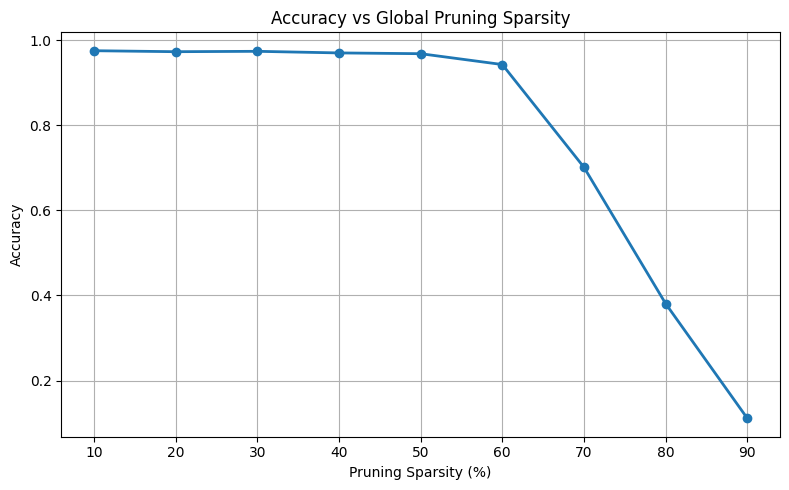

In [42]:
plt.figure(figsize=(8,5))

plt.plot(
    sparsity_levels*100,
    accuracy_list,
    marker='o',
    linewidth=2
)

plt.xlabel("Pruning Sparsity (%)")
plt.ylabel("Accuracy")

plt.title("Accuracy vs Global Pruning Sparsity")

plt.grid(True)

plt.tight_layout()

plt.show()

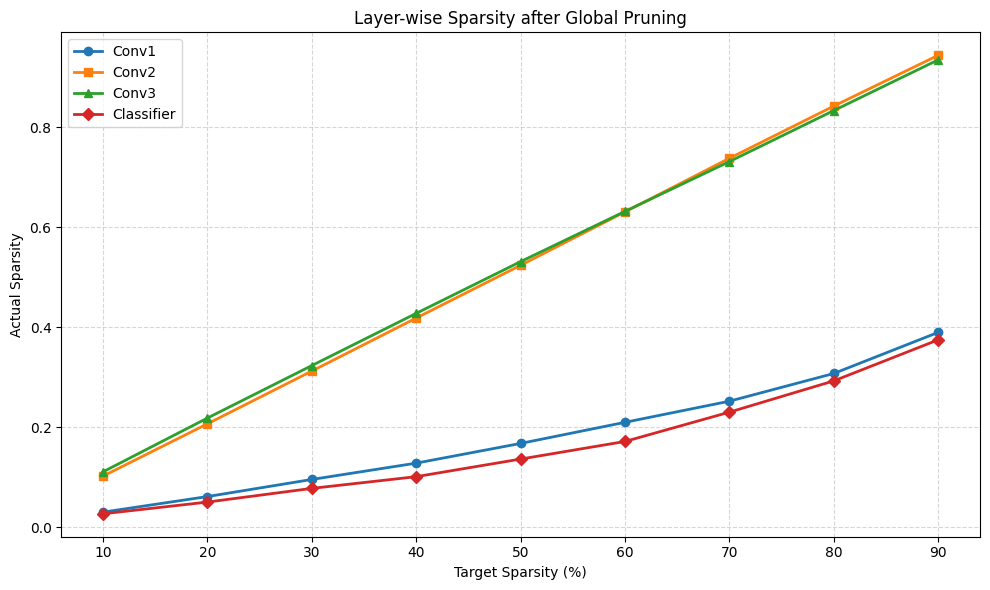

In [41]:
conv1 = []
conv2 = []
conv3 = []
classifier = []

for s in sparsity_levels:

    conv1.append(layer_sparsity[s]["Conv1"])
    conv2.append(layer_sparsity[s]["Conv2"])
    conv3.append(layer_sparsity[s]["Conv3"])
    classifier.append(layer_sparsity[s]["Classifier"])

plt.figure(figsize=(10,6))

plt.plot(sparsity_levels*100,
         conv1,
         marker='o',
         linewidth=2,
         label="Conv1")

plt.plot(sparsity_levels*100,
         conv2,
         marker='s',
         linewidth=2,
         label="Conv2")

plt.plot(sparsity_levels*100,
         conv3,
         marker='^',
         linewidth=2,
         label="Conv3")

plt.plot(sparsity_levels*100,
         classifier,
         marker='D',
         linewidth=2,
         label="Classifier")

plt.xlabel("Target Sparsity (%)")
plt.ylabel("Actual Sparsity")

plt.title("Layer-wise Sparsity after Global Pruning")

plt.grid(True, linestyle="--", alpha=0.5)

plt.legend()

plt.tight_layout()

plt.show()